In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_google_genai  import ChatGoogleGenerativeAI
import operator
from pydantic import BaseModel, Field

load_dotenv()


llm =  ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
class EvaluationSchema(BaseModel):
    feedback : str = Field(description='Detailed feedback for the essay')
    score : int = Field(description='Score out of 10', ge=0, le=10)

llm_structured = llm.with_structured_output(schema=EvaluationSchema)

In [3]:
essay = '''
Artificial Intelligence (AI) is rapidly transforming the way we live, work, and interact. From healthcare to education, transportation to communication, AI is no longer a distant concept but a present reality shaping our future. Its potential lies not only in automating tasks but in augmenting human capabilities, enabling us to solve problems once thought impossible.

In healthcare, AI can analyze medical data to detect diseases earlier and recommend personalized treatments. In education, intelligent systems can adapt to individual learning styles, making knowledge more accessible. Industries benefit from AI-driven efficiency, reducing waste and optimizing production. Even in everyday life, AI assistants simplify tasks, freeing time for creativity and human connection.

However, the future of AI also raises important questions. Ethical concerns about privacy, bias, and job displacement must be addressed to ensure technology serves humanity rather than undermines it. Collaboration between governments, industries, and communities will be essential to create frameworks that balance innovation with responsibility.

Ultimately, AI holds the promise of a future where humans and machines work together to build a more sustainable, equitable, and intelligent world. If guided wisely, it can become not just a tool of progress, but a partner in shaping a better tomorrow.
'''

In [4]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 .{essay}'
result = llm_structured.invoke(prompt)
result

EvaluationSchema(feedback='The essay is exceptionally well-written, demonstrating a high level of proficiency in English. The structure is logical, moving smoothly from an introduction to specific applications, then to critical challenges, and finally to a forward-looking conclusion. The vocabulary is sophisticated and precise, and the sentence structure is varied and fluid. There are no grammatical errors, and the tone is professional and balanced. It effectively communicates complex ideas with clarity and conciseness.', score=10)

In [5]:
class EssayState(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    indivisual_scores:Annotated[list[str], operator.add]
    avg_score:float

In [6]:
graph = StateGraph(EssayState)

In [7]:
def evaluate_language(state:EssayState):
    essay = state['essay']
    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10.{essay}'
    output = llm_structured.invoke(prompt)
    return {'language_feedback':output.feedback,
            'indivisual_scores' : [output.score]}

def evaluate_analysis(state:EssayState):
    essay = state['essay']
    prompt = f'Evaluate the depth analysis of the following essay and provide a feedback and assign a score out of 10 \
    .{essay}'
    output = llm_structured.invoke(prompt)
    return {'analysis_feedback':output.feedback,
            'indivisual_scores' : [output.score]}

def evaluate_thought(state:EssayState):
    essay = state['essay']
    prompt = f'Evaluate the clarity of the following essay and provide a feedback and assign a score out of 10 \
    .{essay}'
    output = llm_structured.invoke(prompt)
    return {'clarity_feedback':output.feedback,
            'indivisual_scores' : [output.score]}

def final_evaluation(state:EssayState):
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = llm.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['indivisual_scores'])/len(state['indivisual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}
    





In [8]:
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language','final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

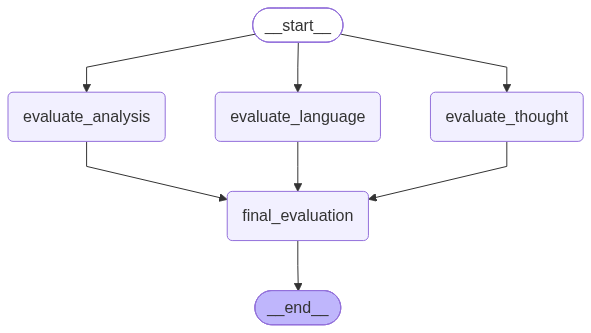

In [9]:
workflow

In [10]:
initial_state = {'essay':essay}

final_result = workflow.invoke(initial_state)
final_result

{'essay': '\nArtificial Intelligence (AI) is rapidly transforming the way we live, work, and interact. From healthcare to education, transportation to communication, AI is no longer a distant concept but a present reality shaping our future. Its potential lies not only in automating tasks but in augmenting human capabilities, enabling us to solve problems once thought impossible.\n\nIn healthcare, AI can analyze medical data to detect diseases earlier and recommend personalized treatments. In education, intelligent systems can adapt to individual learning styles, making knowledge more accessible. Industries benefit from AI-driven efficiency, reducing waste and optimizing production. Even in everyday life, AI assistants simplify tasks, freeing time for creativity and human connection.\n\nHowever, the future of AI also raises important questions. Ethical concerns about privacy, bias, and job displacement must be addressed to ensure technology serves humanity rather than undermines it. Co